In [3]:
library('tidymodels')
library('readr')


Attaching package: ‘readr’

The following object is masked from ‘package:yardstick’:

    spec

The following object is masked from ‘package:scales’:

    col_factor



In [5]:
gss = read_csv('https://raw.githubusercontent.com/UNC-BIOS-512/jupyterlite/refs/heads/main/data/gss_subset.csv')

gss |> glimpse()

Rows: 75699 Columns: 8── Column specification ───────────────────────────────────────────────────────────────────────────────
Delimiter: ","
dbl (8): year, id, age, educ, sex, gunlaw, grass, realinc
ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

Rows: 75,699
Columns: 8
$ year    <dbl> 1972, 1972, 1972, 1972, 1972, 1972, 1972, 1972, 1972, 1972, 19…
$ id      <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18,…
$ age     <dbl> 23, 70, 48, 27, 61, 26, 28, 27, 21, 30, 30, 56, 54, 49, 41, 54…
$ educ    <dbl> 16, 10, 12, 17, 12, 14, 13, 16, 12, 12, 13, 6, 9, 8, 9, 14, 14…
$ sex     <dbl> 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 2, 1, 1, 2, 1, 1, 1, 2, 2, 2, 1,…
$ gunlaw  <dbl> 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 1, NA…
$ grass   <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA…
$ realinc <dbl> 18951, 24366, 24366, 30458, 50763, 43994, 37226, 13537, 2707, …


In [7]:
# step 1
mod = linear_reg()

mod

Linear Regression Model Specification (regression)

Computational engine: lm 


In [8]:
# step 2, "fitting" the model
mod_fit = mod |> fit(realinc ~ educ, data = gss)

mod_fit

parsnip model object


Call:
stats::lm(formula = realinc ~ educ, data = data)

Coefficients:
(Intercept)         educ  
     -14472         3576  


In [23]:
options(repr.plot.res = 250, repr.plot.height = 4, repr.plot.width = 8)

In [29]:
# plot some predictions

gss2 = predict(mod_fit, gss) |>
    bind_cols(gss)

gss2 |> glimpse()

Rows: 75,699
Columns: 9
$ .pred   <dbl> 42743.459, 21287.658, 28439.592, 46319.426, 28439.592, 35591.5…
$ year    <dbl> 1972, 1972, 1972, 1972, 1972, 1972, 1972, 1972, 1972, 1972, 19…
$ id      <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18,…
$ age     <dbl> 23, 70, 48, 27, 61, 26, 28, 27, 21, 30, 30, 56, 54, 49, 41, 54…
$ educ    <dbl> 16, 10, 12, 17, 12, 14, 13, 16, 12, 12, 13, 6, 9, 8, 9, 14, 14…
$ sex     <dbl> 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 2, 1, 1, 2, 1, 1, 1, 2, 2, 2, 1,…
$ gunlaw  <dbl> 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 1, NA…
$ grass   <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA…
$ realinc <dbl> 18951, 24366, 24366, 30458, 50763, 43994, 37226, 13537, 2707, …


Warning message:
“Removed 7968 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 286 rows containing missing values or values outside the scale range (`geom_line()`).”


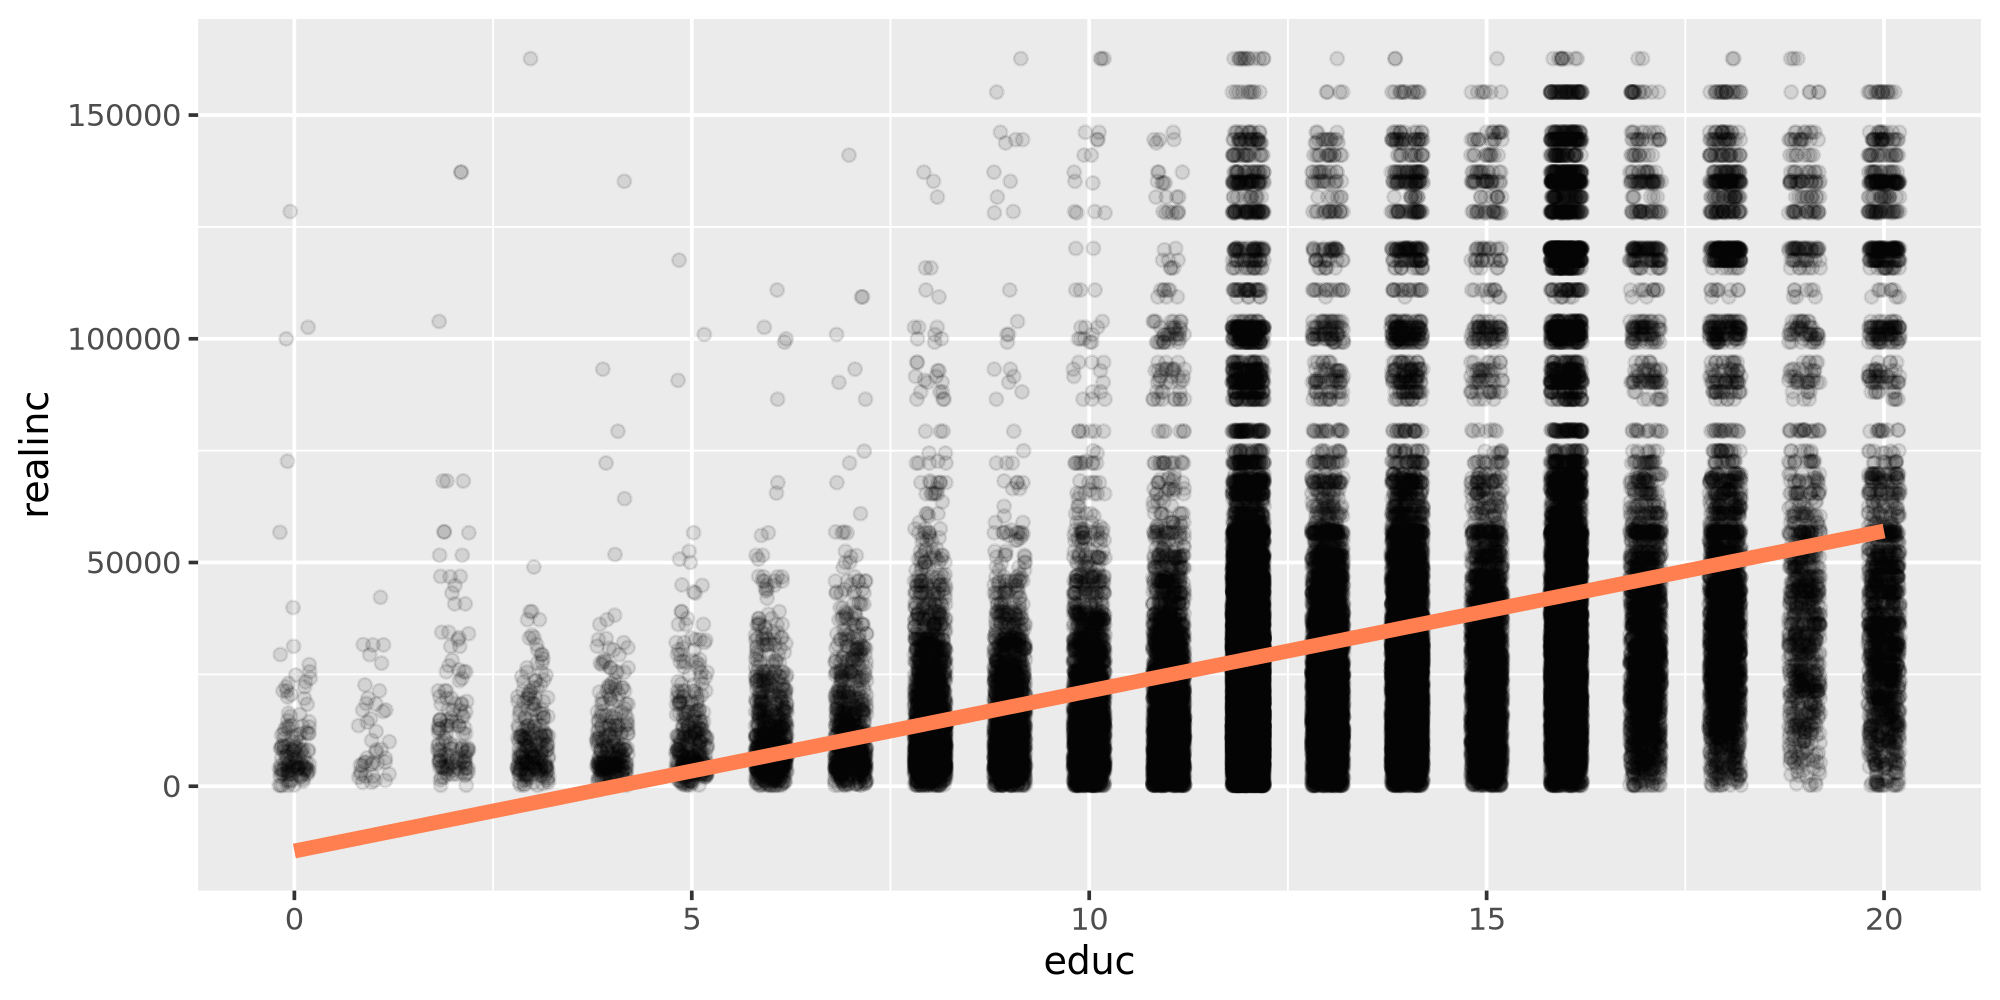

In [31]:
ggplot(gss2, aes(x = educ, y = realinc)) + 
    geom_point(alpha = 0.1, position = position_jitter(width = 0.2)) +
    geom_line(aes(y = .pred), linewidth = 2, color = 'coral')